![Header](header.png)

<div align="center">



    
### Mesh Bayesian Optimisation for manifold-constrained black-box optimisation


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1A0-eSWHt5LHLX-ual3sWgKXp9eLqvzLU?usp=sharing)
[![GitHub](https://img.shields.io/badge/GitHub-repository-181717?logo=github)](https://github.com/aum3/Mesh-Manifold-Bayesian-Optimisation)
![Python](https://img.shields.io/badge/python-3.10%2B-blue)

**Aum Dave** · University of Warwick

</div>

> **Summary::** a demo of Bayesian optimisation (BO) on meshes, for black-box functions that are only defined on a surface.

---
## 1. Introduction

> **How do you optimise a function you know nothing of?** No derivatives, closed form etc. and every evaluation is expensive? Bayesian optimisation handles this with well-defined, testable statistical assumptions, which is why it is so popular wherever evaluations cost real money or time (materials, molecules, engineering design).

### 1.1 Problem

$$
x^\star = \arg\min_{x \in \mathcal{M}} f(x)
$$

where $\mathcal{M}$ is a 2D manifold (surface) embedded in $\mathbb{R}^3$ and $f$ is an expensive black-box function.

### 1.2 Existing approaches

- **Closed-form kernels** exist where the Laplace-Beltrami eigendecomposition is known ($S^n$, $T^n$, etc.).
- **Approximations** cover general manifolds, e.g. a weighted graph built from a point cloud.

### 1.3 My approach

Use a **mesh** as the approximation. Mesh Laplacians are well studied (spectral geometry, FEA), and meshes carry more geometric information than graphs.

1. Sample 100 points from the manifold.
2. Fit a mesh with Poisson surface reconstruction, which comes with strong theoretical guarantees.
3. Use the Mesh matern kernel.
4. Since this is an approximation of an approximation, check the kernel against the exact one on a unit sphere.



---
## 2. Setup



In [1]:
%%capture
#@title Setup
%pip install -q geometric_kernels pymanopt kagglehub

from pathlib import Path
from typing import NamedTuple
import urllib.request

UTILS_URL = "https://raw.githubusercontent.com/aum3/Mesh-Manifold-Bayesian-Optimisation/main/mesh_bo_utils.py"
if not Path("mesh_bo_utils.py").exists():
    urllib.request.urlretrieve(UTILS_URL, "mesh_bo_utils.py")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from geometric_kernels.kernels import MaternGeometricKernel
from geometric_kernels.spaces import Hypersphere, Mesh
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import norm

from mesh_bo_utils import (
    apply_plot_style, geodesic_distances, nearest_vertex_indices, plot_kernel_comparison,
    plot_kernel_influence, plot_objective, plot_sample_path,
    read_ply_vertices, seed_everything,
)

%matplotlib inline

SEED = 0
rng = seed_everything(SEED)   # change SEED to get a different starting vertex
apply_plot_style()

---
## 3. Mesh and Kernel

**How does knowing $f$ at one point tell you about $f$ elsewhere?**

If you knew it was 22°C in Coventry, you'd guess nearby towns are close to 22°C too. Information spreads with distance. That is what a kernel does.

### The mesh

A mesh is a surface stitched together from triangles. I built mine from the 100-point cloud using Poisson surface reconstruction (PSR), which fits a smooth implicit surface to the points and extracts a triangle mesh from it.

<a title="Chrschn, Public domain, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Dolphin_triangle_mesh.png"><img width="330" alt="The polygon mesh of dolphin." src="https://thumb.wikimedia.org/wikipedia/commons/thumb/f/fb/Dolphin_triangle_mesh.png/330px-Dolphin_triangle_mesh.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a>

### The Laplacian $\Delta$

<a title="Nicoguaro. Based on File:Heat eqn.gif by en:User:Oleg Alexandrov, CC BY 4.0 &lt;https://creativecommons.org/licenses/by/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Heat.gif"><img width="330" alt="Animation of the heat equation with a crescent moon as initial condition." src="https://thumb.wikimedia.org/wikipedia/commons/thumb/0/01/Heat.gif/330px-Heat.gif?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a>

Heat spreads by averaging: a point hotter than its neighbours cools, a colder one warms. The Laplacian measures that gap (value at a point minus the average of its neighbours), so it gives the rate of change. On a surface we use the Laplace-Beltrami operator.

Matérn kernels are built from the eigenfunctions of this operator, so they inherit the geometry of the surface and spread information the way heat would.

### The Matérn kernel

- **Lengthscale** $\ell$: how far correlations reach across the surface.
- **Smoothness** $\nu$: how rough the sampled functions are.

That control over roughness is why Matérn kernels suit real-world data, where functions can be continuous but not differentiable.

In [2]:
%%capture

data_dir = Path(kagglehub.dataset_download("aumdave3/obj-file"))
PLY_PATH = data_dir / "100 POINTS ONE.ply"

mesh = Mesh.load_mesh(str(PLY_PATH))
print("num_vertices:", mesh.num_vertices)

kernel = MaternGeometricKernel(mesh)

LENGTHSCALE, NU = 1.0, 0.5
params = kernel.init_params()
params["lengthscale"] = np.array([LENGTHSCALE])
params["nu"] = np.array([NU])

---
## 4. Objective Function

> **This is what we are trying to minimise.** In practice it could be a temperature or the water solubility of a molecule. Both are costly to measure.

For demonstration I use $f(x, y, z) = x$. The method works for any continuous function, provided the kernel suits it.

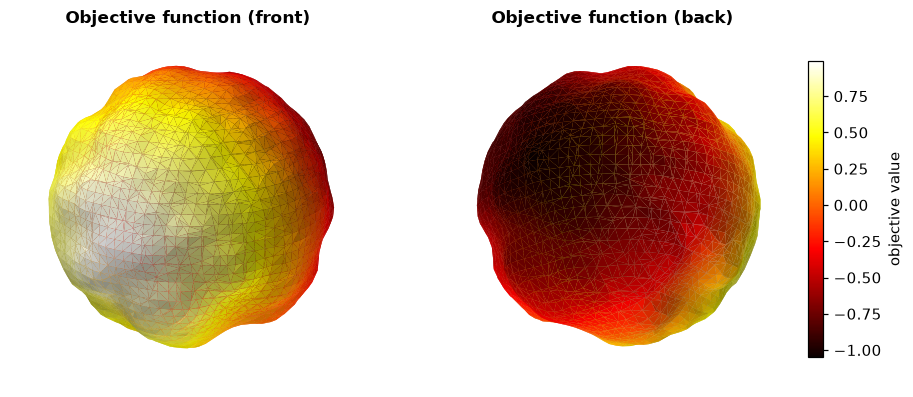

In [3]:
def f(idx):
    # objective = x-coordinate of the vertex. takes 0-based vertex indices
    return mesh.vertices[np.asarray(idx, dtype=np.int64).ravel(), 0]


objective_vals = f(np.arange(mesh.num_vertices))   # ground truth on every vertex

plot_objective(mesh, objective_vals)
plt.show()

### What you're looking at

The ground-truth objective on the mesh. The mesh isn't a perfect sphere because it was built from only 100 points. That is deliberate: the method should still work when the manifold is unknown or only hypothesised.

---
## 5. Bayesian Optimisation

> **In short:** treat $f(x)$ at every point as a Gaussian random variable. Together these give a distribution over plausible functions: a Gaussian process (GP).

The kernel ties the variables together. Once $f(x)$ is known, $k(x, y)$ constrains what $f(y)$ can be at every other point $y$.

**The loop**

0. Start with a prior mean $\mu(x)$ and standard deviation $\sigma(x)$ at every point.
1. Evaluate $f$ at a chosen point $x$.
2. Condition the GP on the data. The kernel updates $\mu$ and $\sigma$ at *every* point (now the posterior).
3. Pick the next $x$ using an acquisition function, and repeat while tracking the best value seen.

The only real information is the observed data, and by design there is very little of it. If $f$ were cheap, you wouldn't need BO.

### 5.1 Gaussian-process surrogate

The surrogate is a cheap, differentiable stand-in for $f$. With a zero-mean prior and kernel $k$, conditioning on $m$ observations $(X, \mathbf{y})$ gives

$$
\mu(\cdot) = k(\cdot, X)\,\big[K_{XX} + \sigma^2 I\big]^{-1}\mathbf{y},
\qquad
\Sigma(\cdot,\cdot') = k(\cdot,\cdot') - k(\cdot, X)\,\big[K_{XX} + \sigma^2 I\big]^{-1} k(X, \cdot').
$$

($\sigma^2$ is a small jitter for numerical stability.)

### 5.2 Acquisition function: expected improvement

The acquisition function scores each point by how promising it is to sample next. BO swaps the hard problem (optimise $f$) for an easy one (optimise this score, which is cheap and differentiable).

For minimisation with incumbent $f_{\min}$ and $Z = (f_{\min} - \mu - \xi)/\sigma$:

$$
\mathrm{EI}(x) = (f_{\min} - \mu - \xi)\,\Phi(Z) + \sigma\,\varphi(Z)
$$

$\xi$ trades off exploration against exploitation (larger $\xi$ favours exploring). I use $\xi = 0.9$ here.

In [4]:
def expected_improvement(mean, std, f_best, xi=0.9):
    # EI for *minimisation*: how much below f_best (minus a margin xi) do we expect to land?
    mean, std = mean.reshape(-1, 1), std.reshape(-1, 1)
    gain = f_best - mean - xi
    with np.errstate(divide="ignore", invalid="ignore"):
        z = gain / std
    ei = gain * norm.cdf(z) + std * norm.pdf(z)
    return np.where(std > 1e-10, ei, 0.0)      # no uncertainty -> nothing to gain


class BOStep(NamedTuple):
    # snapshot after conditioning on the points in x_obs[:-1]. the last row of
    # x_obs / y_obs is the point EI picked next (and its objective value)
    mean: np.ndarray
    variance: np.ndarray
    ei: np.ndarray
    x_obs: np.ndarray
    y_obs: np.ndarray


def run_bo(n_iter, x_init, objective=f, xi=0.9, jitter=1e-6):
    n = mesh.num_vertices
    every_vertex = np.arange(n).reshape(-1, 1)

    K_prior = kernel.K(params, every_vertex, every_vertex)    # n x n, only computed once
    prior_var = np.diag(K_prior)
    prior_mean = np.zeros((n, 1))

    x_obs = np.asarray(x_init, dtype=np.int64).reshape(-1, 1)
    y_obs = objective(x_obs).reshape(-1, 1)

    history = []
    for _ in range(n_iter):
        idx = x_obs.ravel()
        K_xx = K_prior[np.ix_(idx, idx)] + jitter * np.eye(len(idx))
        K_xX = K_prior[idx]                                   # (m, n)

        # one solve covers both K_xx^-1 (y - m) and K_xx^-1 K_xX
        sol = np.linalg.solve(K_xx, np.hstack([y_obs - prior_mean[idx], K_xX]))
        mean = prior_mean + K_xX.T @ sol[:, :1]
        # only the diagonal of the posterior covariance is needed, so skip the n x n product
        variance = np.clip(prior_var - np.sum(K_xX * sol[:, 1:], axis=0), 0, None).reshape(-1, 1)

        ei = expected_improvement(mean, np.sqrt(variance), y_obs.min(), xi)

        x_next = int(np.argmax(ei))
        y_next = np.asarray(objective([x_next])).reshape(-1, 1)
        x_obs = np.vstack([x_obs, [[x_next]]])
        y_obs = np.vstack([y_obs, y_next])
        history.append(BOStep(mean, variance, ei, x_obs, y_obs))

    return history

---
## 6. Mesh BO in action: Posterior Evolution

> **Information spreads along the geometry of the mesh.**

### What you're looking at
- BO running over the mesh. Colour is the GP posterior mean: **dark = low** (what we're after), light = high.
- Top row: front of the mesh. Bottom row: back.
- Orange dots are points already sampled. The red diamond is where expected improvement wants to sample next.

### What to notice
- The search stays in one region for a few steps (exploiting), then jumps to a distant part of the mesh (exploring).
- The dark basin on the back sharpens with each sample, while the front needs no more evaluations after the first two.
- The mesh has about 4,000 vertices, yet a handful of evaluations gets close to the true minimum (numbers below).

> **Each observation is spread across the surface by the kernel, so the optimiser needs far fewer evaluations.**

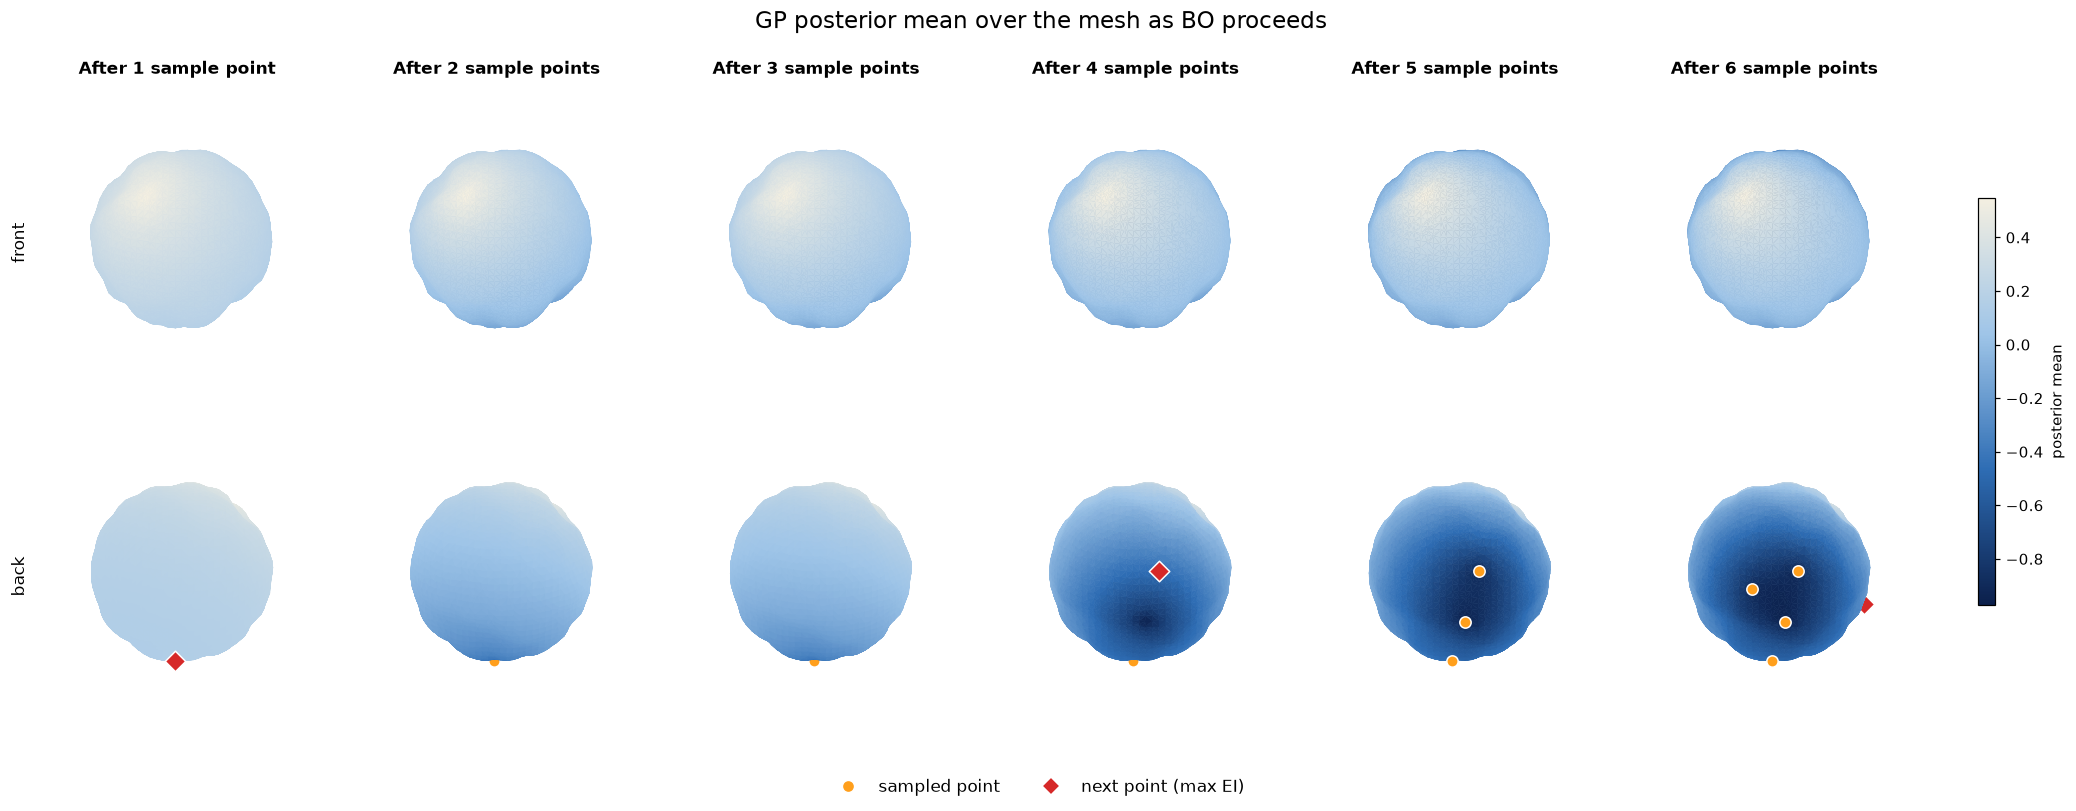

initial vertex value: 0.5475596189498901
sampled values (sorted, incl. initial): [-0.97176754 -0.91938204 -0.91281438 -0.47099268 -0.26728225  0.00433171
  0.54755962]
true minimum: -1.0502488613128662 at vertex 1976


In [5]:
# light -> dark colour scheme: dark = low posterior mean (the minimum we are hunting)
BO_CMAP = LinearSegmentedColormap.from_list("bo_dark_light", ["#0B1F4B", "#2E6DB4", "#9FC5E8", "#F4EFE1"])


def plot_bo_evolution(mesh, history, cmap=BO_CMAP):
    """Posterior mean after each BO step. Top row: front (+x side). Bottom row: back."""
    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.faces)
    norm_ = plt.Normalize(min(h.mean.min() for h in history), max(h.mean.max() for h in history))
    views = [("front", 20, 0), ("back", 20, 180)]        # (label, elevation, azimuth)
    lim = np.abs(verts).max()

    fig = plt.figure(figsize=(3.3 * len(history), 7.4))
    for r, (label, elev, azim) in enumerate(views):
        cam = np.array([np.cos(np.radians(elev)) * np.cos(np.radians(azim)),
                        np.cos(np.radians(elev)) * np.sin(np.radians(azim)),
                        np.sin(np.radians(elev))])
        for c, h in enumerate(history):
            ax = fig.add_subplot(2, len(history), r * len(history) + c + 1, projection="3d")
            colours = cmap(norm_(h.mean.ravel()[faces].mean(axis=1)))
            ax.add_collection3d(Poly3DCollection(verts[faces], facecolors=colours,
                                                 edgecolors=colours, linewidths=0.3))
            ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
            ax.set_box_aspect((1, 1, 1)); ax.view_init(elev, azim); ax.set_axis_off()

            sampled, nxt = h.x_obs.ravel()[:-1], h.x_obs.ravel()[-1]
            seen = lambda i: verts[i] @ cam > 0             # only mark the side facing the camera
            ax.scatter(*(verts[sampled][seen(sampled)] * 1.02).T, s=55, c="#FF9F1C",
                       edgecolor="white", linewidth=1, depthshade=False, zorder=10)
            if seen(nxt):
                ax.scatter(*(verts[nxt] * 1.02), s=90, marker="D", c="#D62828",
                           edgecolor="white", linewidth=1, depthshade=False, zorder=11)
            if r == 0:
                ax.set_title(f"After {c + 1} sample point{'s' if c else ''}", fontsize=11, fontweight="bold")
            if c == 0:
                ax.text2D(-0.02, 0.5, label, transform=ax.transAxes, rotation=90, va="center", fontsize=11)

    fig.suptitle("GP posterior mean over the mesh as BO proceeds", fontsize=15, y=0.98)
    fig.colorbar(cm.ScalarMappable(norm=norm_, cmap=cmap), cax=fig.add_axes([0.93, 0.25, 0.008, 0.5]),
                 label="posterior mean")
    fig.legend(handles=[Line2D([], [], marker="o", ls="", color="#FF9F1C", mec="white", ms=8, label="sampled point"),
                        Line2D([], [], marker="D", ls="", color="#D62828", mec="white", ms=8, label="next point (max EI)")],
               loc="lower center", ncol=2, frameon=False, fontsize=11)
    fig.subplots_adjust(left=0.03, right=0.91, top=0.9, bottom=0.08, wspace=0, hspace=0)
    return fig


initial_vertex = int(rng.integers(mesh.num_vertices))
NUM_STEPS = 6

history = run_bo(NUM_STEPS, x_init=[initial_vertex])

plot_bo_evolution(mesh, history)
plt.show()

final = history[-1]
best = np.argmin(objective_vals)
print("initial vertex value:", objective_vals[initial_vertex])
print("sampled values (sorted, incl. initial):", np.sort(final.y_obs.ravel()))
print("true minimum:", objective_vals[best], "at vertex", best)

---
## 7. Sample Path

> **Which route did the optimiser take?** (A slightly different set-up from section 6.)

### What you're looking at
Numbers show the order in which vertices were sampled, joined by curves that follow the surface. Left: ground-truth objective. Right: the GP posterior mean after 3 sample points.

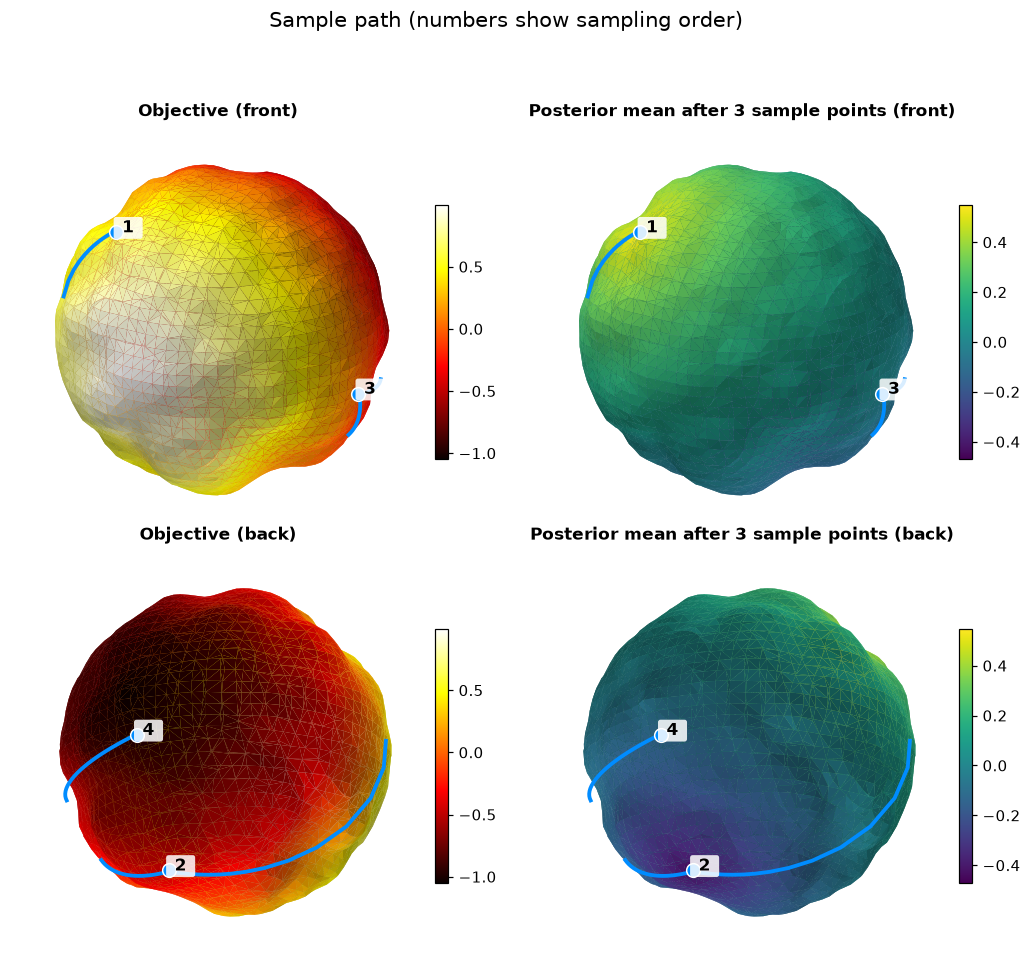

In [6]:
after_three = history[2]

plot_sample_path(mesh, objective_vals, after_three.mean, after_three.x_obs,
                 posterior_label="Posterior mean after 3 sample points")
plt.show()

---
## 8. Kernel Influence

> **What does one observation tell the model about the rest of the surface?**

### What you're looking at
Heat map of $k(x_0, \cdot)$ for a single source vertex $x_0$ (red diamond). Bright = strongly correlated with the source.

### What it means
Correlation fades with distance *along the surface*, as if $x_0$ were a heat source. That is the geometry we wanted the kernel to capture.

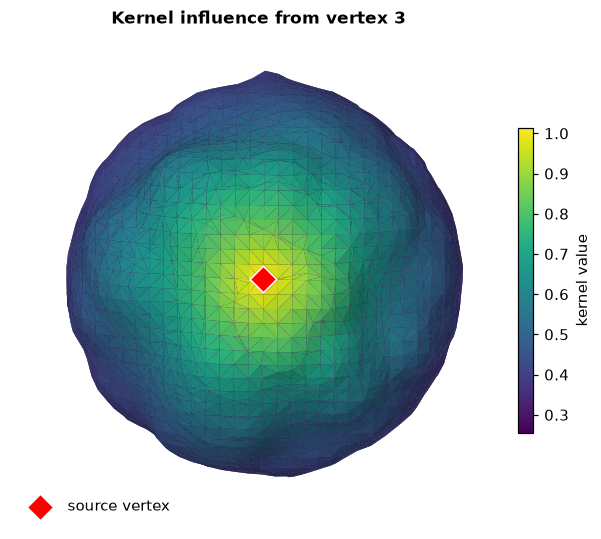

: 

In [ ]:
SOURCE_VERTEX = 3

plot_kernel_influence(mesh, kernel, params, SOURCE_VERTEX)
plt.show()

---
## 9. Error Analysis

> **How much do we lose by using a mesh instead of the smooth manifold?**

### Setup
The 100 points were sampled from a sphere, so a "true" kernel exists. I take the same points and compare (a) the mesh kernel at their nearest mesh vertices with (b) the continuous Matérn kernel on $S^2$, using identical hyperparameters. Both are plotted against geodesic distance.

### What you're looking at
Red: mesh kernel. Blue: continuous sphere kernel. Each dot is a pair of points (a random subset, to keep the plot readable).

In [ ]:
ply_points = read_ply_vertices(PLY_PATH)                       # raw point cloud
sphere_points = ply_points / np.linalg.norm(ply_points, axis=1, keepdims=True)

# discretised kernel: snap each point to its nearest mesh vertex
vertex_ids = nearest_vertex_indices(sphere_points, mesh.vertices)
mesh_K = kernel.K(params, vertex_ids, vertex_ids)

# continuous kernel on S^2, same hyperparameters
sphere_kernel = MaternGeometricKernel(Hypersphere(dim=2))
sphere_K = sphere_kernel.K(params, sphere_points, sphere_points)

geo_dist = geodesic_distances(sphere_points)

print(f"RMS difference between the two kernels: {np.sqrt(np.mean((mesh_K - sphere_K) ** 2)):.4f}")

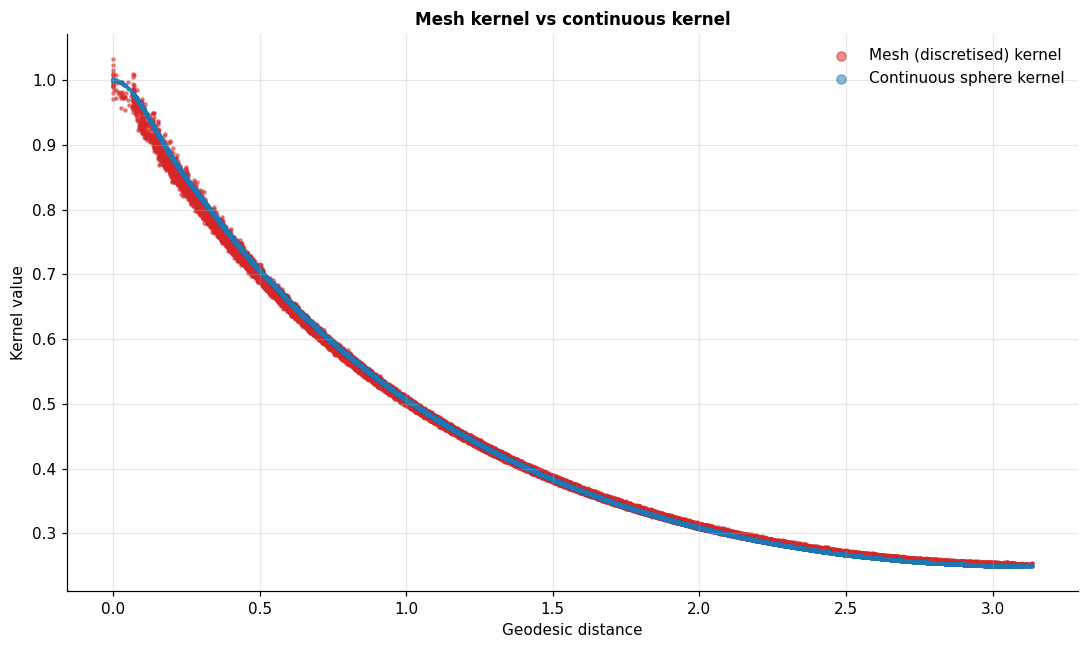

In [ ]:
plot_kernel_comparison(geo_dist, mesh_K, sphere_K)
plt.show()

---
## 10. Conclusions and Future Work

Bayesian optimisation on meshes is viable: a mesh built from just 100 points gave a kernel that tracks the true sphere kernel closely.

### Results
- The mesh kernel is very close to the continuous one (RMS difference 0.0055).
- That held even though the mesh is an approximation built from 100 random points.
- BO reached a value of -0.97 against a true minimum of -1.05, using 7 evaluations out of about 4,000 vertices (seed 0).

### Limitations
- One mesh, one manifold, one objective, one seed.
- Manifolds with small reach or other pathologies may not survive meshing, and mesh Laplacians are sensitive to mesh quality.

### Future work
- Repeat over many seeds and objectives, and compare against random search.
- Test on non-spherical manifolds and real data.

---
## 11. References and Links

### References
1. Borovitskiy et al., "Matérn Gaussian processes on Riemannian manifolds", NeurIPS 2020.
2. Kazhdan, Bolitho and Hoppe, "Poisson surface reconstruction", Eurographics SGP 2006.

### Links
- **Code:** [GitHub repository](https://github.com/aum3/Mesh-Manifold-Bayesian-Optimisation)
- **Author:** [LinkedIn](https://linkedin.com/in/aumd) · [Email](mailto:aumd39@gmail.com)

### Acknowledgements
Thanks to Dr Zhengang Zhong for supervising this project, and to the University of Warwick for funding it.